In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_style('whitegrid', rc={'ytick.left': True, 'ytick.color': 'silver'})
plt.rcParams['axes.autolimit_mode'] = 'round_numbers'
plt.rcParams['ytick.labelcolor'] = 'black'
sns.set_palette('colorblind')

In [3]:
df = pd.read_csv('sites.csv')

In [4]:
# KEY = 'RAPL package-0 (J)'
KEY = 'INA system energy (J)'

In [5]:
df['sort'] = df.groupby('url')[KEY].transform('mean')
df = df.sort_values(by='sort', ascending=False).drop('sort', axis=1).reset_index(drop=True)

In [6]:
df_mean = df.groupby('url').mean()
df_mean.describe()

,transferSize,decodedBodySize,resourceCount,scriptCount,imageCount,divCount,Runtime,RAPL package-0 (J),RAPL package-0-core (J),RAPL package-0-uncore (J),INA system energy (J)
count,1117.000000,1.117000e+03,1117.000000,1117.000000,1117.000000,1117.000000,1117.000000,1117.000000,1117.000000,1117.000000,1117.000000
mean,28982.346315,1.143192e+05,38.710236,22.126977,11.765891,137.289317,4.488010,2.692881,1.259157,0.000057,5.873254
std,36877.541327,1.145109e+05,26.268874,18.425474,16.888312,154.860080,1.753384,2.394827,1.397074,0.000032,4.998038
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,4.012280,0.203520,0.051853,0.000000,0.707947
25%,10277.000000,3.912600e+04,23.000000,9.000000,4.000000,65.000000,4.138940,1.251280,0.479826,0.000037,2.913494
50%,21129.000000,8.682200e+04,35.000000,18.000000,8.000000,107.000000,4.266353,2.118411,0.962550,0.000049,4.746808
75%,37973.000000,1.702940e+05,53.000000,29.000000,14.000000,170.000000,4.491320,3.201296,1.450333,0.000073,6.866069
max,491472.000000,1.570574e+06,220.000000,140.000000,327.000000,2199.000000,42.702145,25.541936,15.698034,0.000641,56.889228


In [7]:
df_mean.sort_values(by=KEY, ascending=False).head(20)

,transferSize,decodedBodySize,resourceCount,scriptCount,imageCount,divCount,Runtime,RAPL package-0 (J),RAPL package-0-core (J),RAPL package-0-uncore (J),INA system energy (J)
url,,,,,,,,,,,
vnggelderland.nl,12015.0,67929.0,17.0,11.0,18.0,186.0,4.532650,25.541936,15.698034,0.000049,56.889228
technologybase.nl,7173.0,54240.0,50.0,7.0,54.0,191.0,4.430988,22.449088,14.714098,0.000073,48.584061
dethon.nl,13438.0,67902.0,42.0,21.0,21.0,170.0,4.635949,16.093198,9.844659,0.000061,34.852756
werkom.nl,50591.0,353256.0,54.0,30.0,43.0,569.0,5.902112,15.765601,9.490394,0.000098,33.672778
advocatenorde.nl,17376.0,88234.0,45.0,17.0,10.0,177.0,4.391524,15.835113,9.223107,0.000073,33.183956
parklingezegen.nl,23508.0,153286.0,52.0,32.0,75.0,293.0,4.854973,15.387798,7.858548,0.000122,32.023348
bureau-ovl.nl,26487.0,122494.0,77.0,64.0,15.0,146.0,5.114651,14.439411,9.064713,0.000049,30.791041
architectenregister.nl,121772.0,582342.0,28.0,5.0,12.0,310.0,5.187525,14.333703,7.828529,0.000098,29.825327
over.npo.nl,37407.0,215797.0,51.0,31.0,11.0,365.0,4.814815,15.049071,6.431359,0.000024,29.812500


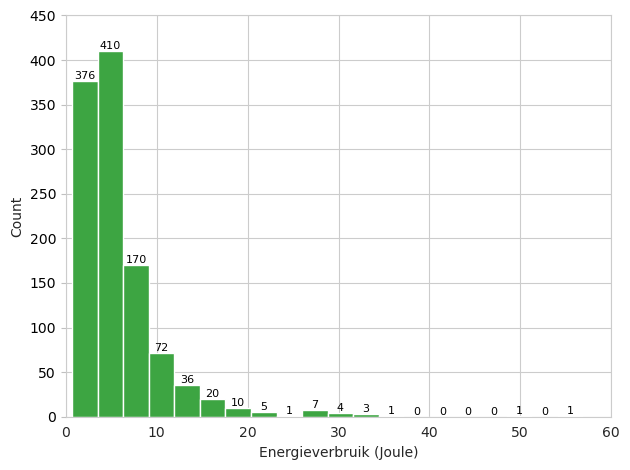

In [8]:
ax = sns.histplot(df_mean, x=KEY, bins=20, color='#3DA542', alpha=1)

c = ax.containers[0]
bins = [rect.get_height() for rect in c]
ax.bar_label(c, color='k', fontsize=8)

plt.xlim(0,None)
plt.xlabel('Energieverbruik (Joule)')
plt.tight_layout()
plt.show()

In [9]:
def squash(s):
    ''' Replace everthing between outermost `/` with dots. '''
    import re
    return re.sub(r'(?<=/).*(?=/)', '...', s) if s.count('/') >= 2 else s

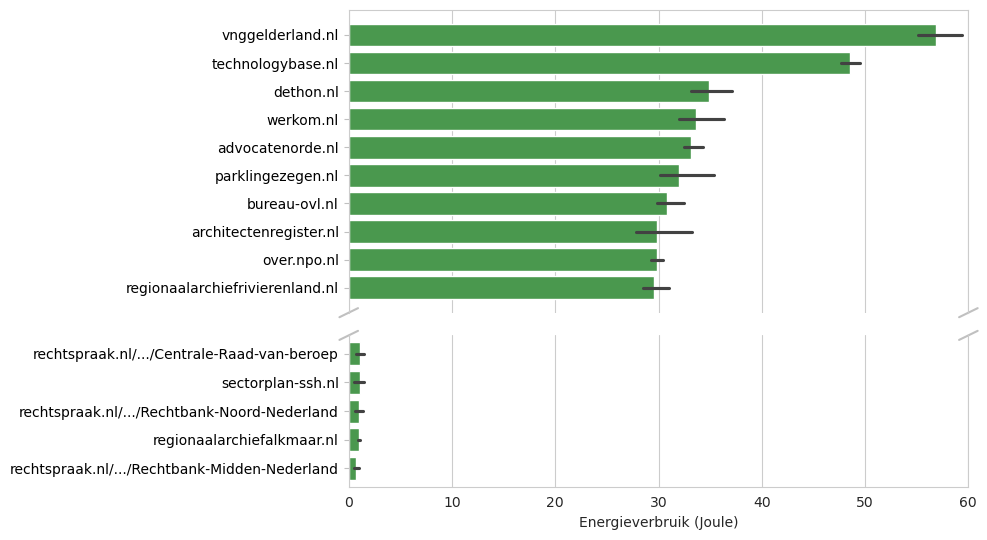

In [10]:
N_TOP, N_BOT = 10, 5
ASPECT = N_TOP / N_BOT
top, bot = df[:(5*N_TOP)], df[-(5*N_BOT):]

fig, (ax0, ax1) = plt.subplots(2, sharex=True, height_ratios=[N_TOP,N_BOT], figsize=(10,5.5))
sns.barplot(y=list(map(squash, top['url'])), x=top[KEY], orient='h', color='#3DA542', ax=ax0)
sns.barplot(y=list(map(squash, bot['url'])), x=bot[KEY], orient='h', color='#3DA542', ax=ax1)
ax1.set_xlabel('Energieverbruik (Joule)')
plt.xlim(0,60)

# Hide spines between axes
ax0.spines['bottom'].set_visible(False)
ax1.spines['top'].set_visible(False)

# Add diagonal break marks
d = .015
kwargs = dict(transform=ax0.transAxes, color='silver', clip_on=False)
ax0.plot((0-d, 0+d), (0-d, 0+d), **kwargs) # left
ax0.plot((1-d, 1+d), (0-d, 0+d), **kwargs) # right
kwargs.update(transform=ax1.transAxes)
ax1.plot((0-d, 0+d), (1-d*ASPECT, 1+d*ASPECT), **kwargs) # left
ax1.plot((1-d, 1+d), (1-d*ASPECT, 1+d*ASPECT), **kwargs) # right

plt.tight_layout()
plt.savefig('rank.png', bbox_inches='tight')
plt.show()